In [1]:
import numpy as np
import matplotlib.pyplot as plt
import corner
import emcee
from scipy.optimize import minimize

In [2]:
def log_likelihood(theta, x, y, yerr):
    m, b, f = theta
    model = m * x + b
    sigma2 = yerr**2 + model**2 * f**2
    return -0.5 * np.sum((y - model) ** 2 / sigma2 + np.log(sigma2))

def log_prior(theta, upper, lower):
    m, b, f = theta
    
    if lower[0] < m < upper[0] and lower[1] < b < upper[1] and lower[2] < f < upper[2]:
        return 0.0
    return -np.inf

def log_probability(theta, x, y, yerr, upper, lower):
    lp = log_prior(theta, upper, lower)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, x, y, yerr)

In [29]:
data = np.genfromtxt("line-1.dat", delimiter=" ", usemask=False)
labels = ['m', 'b', 'f']

x = data[0]
y = data[1]
yerr = data[2]

upper = [5,10,10]
lower = [-5,-10,0]

initial_theta = np.array([-0.0,0.0,0.01])
sigma = np.array([0.01, 0.01, 0.01])
initial_spread = np.array([1,1,0.001])

n_walkers = 10
n_steps = 10000
theta = np.array([np.random.normal(initial_theta, initial_spread) for _ in range(n_walkers)])

sampler = emcee.EnsembleSampler(
    nwalkers, len(initial_spread), log_probability, args=(x, y, yerr, upper, lower)
)
sampler.run_mcmc(theta, n_steps, progress=True);

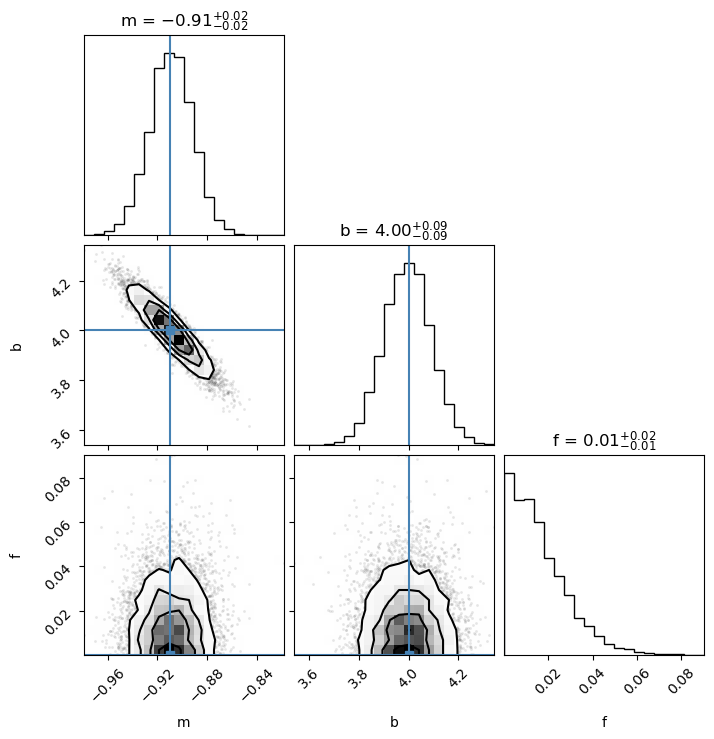

In [30]:
flat_samples = sampler.get_chain(discard=400, thin=15, flat=True)
fig = corner.corner(
    flat_samples, labels=labels, truths=[-0.91,4.0,0.0],show_titles=True);

In [31]:
print('m = ' + str(round(np.median(flat_samples.T[0]),5)))
print('b = ' + str(round(np.median(flat_samples.T[1]),5)))
print('f = ' + str(round(np.median(flat_samples.T[2]),5)))

m = -0.90866
b = 3.99555
f = 0.0134


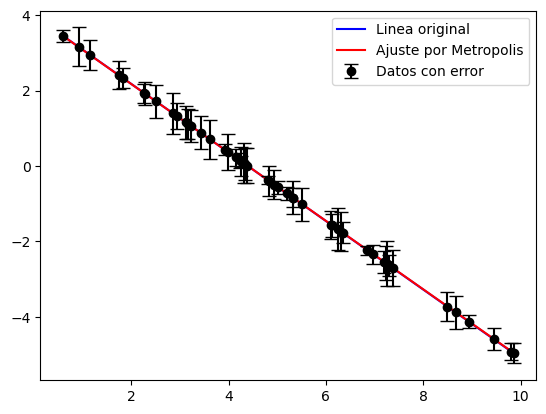

In [32]:
y_ajuste = np.median(flat_samples.T[0])*x + np.median(flat_samples.T[1])
y_real = -0.91*x + 4.0
plt.plot(x, y_real, color = 'blue', label='Linea original')
plt.plot(x, y_ajuste, color = 'red', label='Ajuste con emcee')
plt.errorbar(x, data[1], yerr=data[2], fmt='o', color='black', 
             ecolor='black', capsize=5, label='Datos con error')
plt.legend()

In [41]:
data = np.genfromtxt("line-2.dat", delimiter=" ", usemask=False)
labels = ['m', 'b', 'f']

x = data[0]
y = data[1]
yerr = data[2]

upper = [5,10,10]
lower = [-5,-10,0]

initial_theta = np.array([-0.0,0.0,0.01])
sigma = np.array([0.01, 0.01, 0.01])
initial_spread = np.array([1,1,0.001])

n_walkers = 10
n_steps = 100000
theta = np.array([np.random.normal(initial_theta, initial_spread) for _ in range(n_walkers)])

sampler = emcee.EnsembleSampler(
    nwalkers, len(initial_spread), log_probability, args=(x, y, yerr, upper, lower)
)
sampler.run_mcmc(theta, n_steps, progress=True);

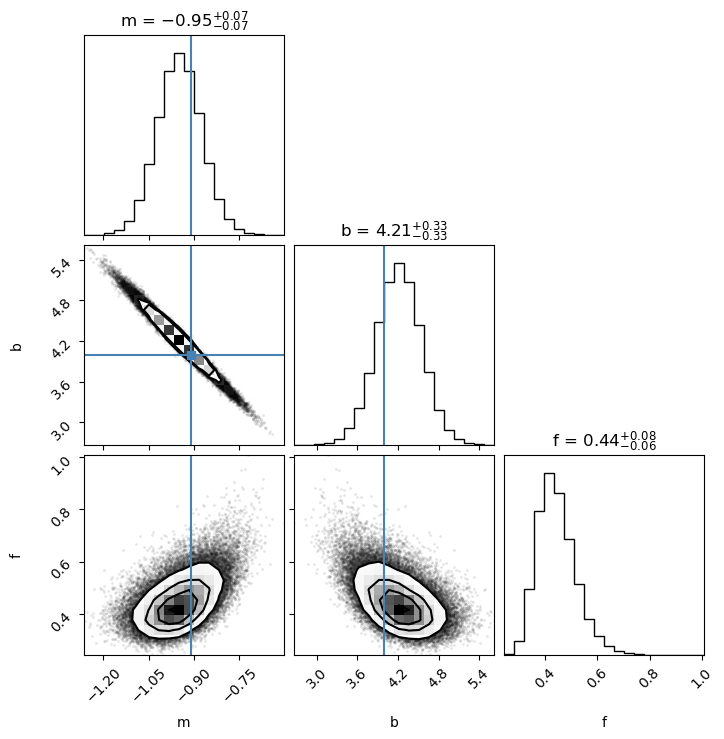

In [47]:
flat_samples = sampler.get_chain(discard=4000, thin=15, flat=True)
fig = corner.corner(
    flat_samples, labels=labels, truths=[-0.91,4.0,0.0],show_titles=True);

In [46]:
print('m = ' + str(round(np.median(flat_samples.T[0][4000:]),5)))
print('b = ' + str(round(np.median(flat_samples.T[1][4000:]),5)))
print('f = ' + str(round(np.median(flat_samples.T[2][4000:]),5)))

m = -0.94962
b = 4.2151
f = 0.43606


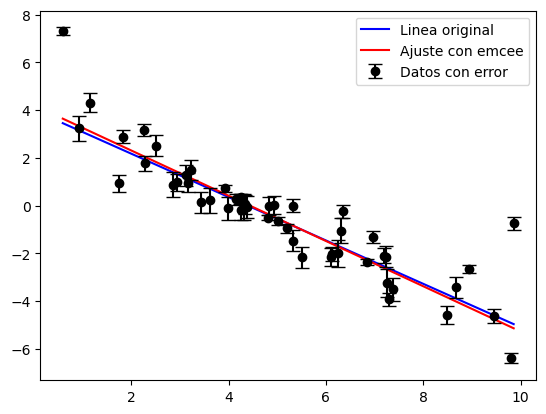

In [44]:
y_ajuste = np.median(flat_samples.T[0])*x + np.median(flat_samples.T[1])
y_real = -0.91*x + 4.0
plt.plot(x, y_real, color = 'blue', label='Linea original')
plt.plot(x, y_ajuste, color = 'red', label='Ajuste con emcee')
plt.errorbar(x, data[1], yerr=data[2], fmt='o', color='black', 
             ecolor='black', capsize=5, label='Datos con error')
plt.legend()